# Optimización de un Modelo de Ensamble
## Selección de características y ajuste de hiperparámetros

---

## 1. Descripción del problema

### Dataset
**Nombre:** Breast Cancer Wisconsin (Diagnostic)
**Fuente:** UCI Machine Learning Repository, incluido en `scikit-learn` como `sklearn.datasets.load_breast_cancer()`
**Autores originales:** Dr. William H. Wolberg, W. Nick Street y Olvi L. Mangasarian, University of Wisconsin.

### El problema
Clasificación binaria en contexto de diagnóstico médico. A partir de mediciones obtenidas de una imagen
digitalizada de una punción con aguja fina de una masa mamaria, se busca determinar si el tumor es
**maligno** o **benigno**.

### Qué representa cada observación
Cada fila corresponde a **una muestra de tejido de una paciente**. Las 30 variables predictoras son
mediciones morfológicas calculadas sobre los núcleos celulares visibles en la imagen: radio, textura,
perímetro, área, suavidad, compacidad, concavidad, simetría y dimensión fractal. De cada una se reportan
tres estadísticos (media, error estándar y "peor" valor), lo que da 10 × 3 = 30 columnas.

### Variable objetivo
`diagnosis`, con dos categorías:
- **0 = maligno** (212 casos, 37.3%)
- **1 = benigno** (357 casos, 62.7%)

### Métrica principal: F1-score de la clase maligna

**Justificación.** En un diagnóstico oncológico los dos tipos de error tienen costos muy distintos:

- Un **falso negativo** (clasificar como benigno un tumor maligno) puede retrasar el tratamiento. Es el error
  más grave.
- Un **falso positivo** genera ansiedad y pruebas adicionales innecesarias, pero es recuperable.

Por eso *accuracy* no sirve como métrica principal: con un 62.7% de casos benignos, un modelo que prediga
siempre "benigno" alcanzaría un 62.7% de accuracy sin detectar **ni un solo** caso maligno.

Se elige **F1-score de la clase maligna** porque combina *recall* (no dejar pasar casos malignos) y
*precision* (no saturar de falsas alarmas) en un solo número, y se calcula sobre la clase minoritaria, que es
justamente la clínicamente relevante.

### Métrica complementaria: ROC-AUC

Mide la capacidad de separación del modelo **independientemente del umbral de decisión**. Es útil porque en
la práctica clínica ese umbral podría moverse para priorizar aún más el recall, y ROC-AUC indica si el modelo
tiene margen para hacerlo.

También se reporta el **recall de la clase maligna** por su relevancia directa en este contexto.


---
## 2. Carga de datos y preparación

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time, warnings
warnings.filterwarnings("ignore")

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import (f1_score, roc_auc_score, recall_score, precision_score,
                             accuracy_score, confusion_matrix, roc_curve, classification_report,
                             make_scorer)

SEED = 42                      # semilla fija: garantiza reproducibilidad
np.random.seed(SEED)

plt.rcParams["figure.dpi"] = 110
# Scorer propio: F1 de la clase MALIGNA (etiqueta 0), que es la métrica principal.
# Sin esto, scoring="f1" de Scikit-learn optimizaría la clase benigna (etiqueta 1) por defecto.
f1_maligno = make_scorer(f1_score, pos_label=0)

print("Librerías cargadas · semilla fija =", SEED)
print("Scorer principal definido: F1 sobre la clase maligna (pos_label=0)")


Librerías cargadas · semilla fija = 42
Scorer principal definido: F1 sobre la clase maligna (pos_label=0)


In [2]:
# Carga del dataset
datos = load_breast_cancer()
X = pd.DataFrame(datos.data, columns=datos.feature_names)
y = pd.Series(datos.target, name="diagnosis")

print("Dimensiones:", X.shape[0], "observaciones ×", X.shape[1], "variables predictoras")
print("\nPrimeras 5 filas (primeras 6 columnas):")
display(X.iloc[:5, :6].round(3))


Dimensiones: 569 observaciones × 30 variables predictoras

Primeras 5 filas (primeras 6 columnas):


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness
0,17.99,10.38,122.80,1001.0,0.118,0.278
1,20.57,17.77,132.90,1326.0,0.085,0.079
2,19.69,21.25,130.00,1203.0,0.110,0.160
3,11.42,20.38,77.58,386.1,0.142,0.284
4,20.29,14.34,135.10,1297.0,0.100,0.133


In [3]:
# --- Revisión de calidad de los datos ---
print("TIPOS DE DATOS")
print(X.dtypes.value_counts().to_string())
print("\nTodas las variables son numéricas continuas -> no se requiere codificación de categóricas.")

print("\n\nVALORES FALTANTES")
faltantes = X.isnull().sum().sum()
print(f"Total de valores nulos: {faltantes}")

print("\n\nDUPLICADOS")
duplicados = X.duplicated().sum()
print(f"Filas duplicadas: {duplicados}")

print("\n\nDISTRIBUCIÓN DE LA VARIABLE OBJETIVO")
conteo = y.value_counts().sort_index()
for clase, n in conteo.items():
    nombre = datos.target_names[clase]
    print(f"  {clase} = {nombre:<10} {n:>4} casos  ({n/len(y)*100:>5.1f}%)")
print(f"\nRatio de desbalance: {conteo.max()/conteo.min():.2f} : 1  -> desbalance moderado.")
print("Se usará ESTRATIFICACIÓN en la partición para conservar estas proporciones.")


TIPOS DE DATOS
float64    30

Todas las variables son numéricas continuas -> no se requiere codificación de categóricas.


VALORES FALTANTES
Total de valores nulos: 0


DUPLICADOS
Filas duplicadas: 0


DISTRIBUCIÓN DE LA VARIABLE OBJETIVO
  0 = malignant   212 casos  ( 37.3%)
  1 = benign      357 casos  ( 62.7%)

Ratio de desbalance: 1.68 : 1  -> desbalance moderado.
Se usará ESTRATIFICACIÓN en la partición para conservar estas proporciones.


In [4]:
# --- Escalas muy distintas: justifica usar un pipeline con escalado ---
resumen = X.describe().T[["mean", "std", "min", "max"]]
print("Variables con mayor y menor escala:\n")
display(pd.concat([resumen.nlargest(3, "mean"), resumen.nsmallest(3, "mean")]).round(4))
print(f"Rango de las medias: de {resumen['mean'].min():.4f} a {resumen['mean'].max():.1f}")
print("-> Diferencias de varios órdenes de magnitud. Se incluye StandardScaler en el pipeline.")


Variables con mayor y menor escala:



,mean,std,min,max
worst area,880.5831,569.3570,185.2000,4254.0000
mean area,654.8891,351.9141,143.5000,2501.0000
worst perimeter,107.2612,33.6025,50.4100,251.2000
fractal dimension error,0.0038,0.0026,0.0009,0.0298
smoothness error,0.0070,0.0030,0.0017,0.0311
concave points error,0.0118,0.0062,0.0000,0.0528


Rango de las medias: de 0.0038 a 880.6
-> Diferencias de varios órdenes de magnitud. Se incluye StandardScaler en el pipeline.


In [5]:
# --- Partición entrenamiento / prueba (80 / 20, estratificada, semilla fija) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f"Entrenamiento: {X_train.shape[0]} observaciones ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Prueba       : {X_test.shape[0]} observaciones ({X_test.shape[0]/len(X)*100:.0f}%)")

print("\nProporción de la clase maligna:")
print(f"  Conjunto completo : {(y == 0).mean()*100:.2f}%")
print(f"  Entrenamiento     : {(y_train == 0).mean()*100:.2f}%")
print(f"  Prueba            : {(y_test == 0).mean()*100:.2f}%")
print("\nLa estratificación conservó las proporciones en ambos conjuntos.")


Entrenamiento: 455 observaciones (80%)
Prueba       : 114 observaciones (20%)

Proporción de la clase maligna:
  Conjunto completo : 37.26%
  Entrenamiento     : 37.36%
  Prueba            : 36.84%

La estratificación conservó las proporciones en ambos conjuntos.


---
## 3. Modelo base

Se utiliza **Random Forest**, un algoritmo de ensamble que combina múltiples árboles de decisión entrenados
sobre muestras y subconjuntos de variables distintos, y promedia sus votos.

Se emplea la **configuración predeterminada** de Scikit-learn (100 árboles, sin límite de profundidad,
`max_features='sqrt'`), fijando únicamente la semilla. Esta configuración constituye el punto de partida
documentado contra el que se compararán las mejoras posteriores.

El modelo se envuelve en un **Pipeline** junto con `StandardScaler` para que todo el preprocesamiento se
aplique de forma consistente y ajustándose solo con los datos de entrenamiento.


In [6]:
# --- Función de evaluación reutilizable (garantiza métricas idénticas en los 3 modelos) ---
def evaluar(modelo, X_tr, y_tr, X_te, y_te, nombre, n_caracteristicas):
    t0 = time.perf_counter()
    modelo.fit(X_tr, y_tr)
    t_entrenamiento = time.perf_counter() - t0

    y_pred = modelo.predict(X_te)
    y_proba = modelo.predict_proba(X_te)[:, 1]

    # pos_label=0 -> las métricas se calculan sobre la clase MALIGNA
    resultados = {
        "Modelo": nombre,
        "Características": n_caracteristicas,
        "F1 (maligno)": f1_score(y_te, y_pred, pos_label=0),
        "ROC-AUC": roc_auc_score(y_te, y_proba),
        "Recall (maligno)": recall_score(y_te, y_pred, pos_label=0),
        "Precision (maligno)": precision_score(y_te, y_pred, pos_label=0),
        "Accuracy": accuracy_score(y_te, y_pred),
        "Tiempo (s)": t_entrenamiento,
    }
    return resultados, modelo, y_pred, y_proba

print("Función de evaluación definida.")
print("Métrica principal: F1 de la clase maligna (pos_label=0)")
print("Métrica complementaria: ROC-AUC")


Función de evaluación definida.
Métrica principal: F1 de la clase maligna (pos_label=0)
Métrica complementaria: ROC-AUC


In [7]:
# --- Entrenamiento del modelo base ---
pipeline_base = Pipeline([
    ("escalado", StandardScaler()),
    ("modelo", RandomForestClassifier(random_state=SEED, n_jobs=-1)),
])

res_base, modelo_base, pred_base, proba_base = evaluar(
    pipeline_base, X_train, y_train, X_test, y_test,
    nombre="Base", n_caracteristicas=X_train.shape[1]
)

print("MODELO BASE — Random Forest con parámetros predeterminados\n")
for k, v in res_base.items():
    if isinstance(v, float):
        print(f"  {k:<22} {v:.4f}")
    else:
        print(f"  {k:<22} {v}")

print("\n\nReporte de clasificación detallado:")
print(classification_report(y_test, pred_base, target_names=["maligno", "benigno"], digits=4))


MODELO BASE — Random Forest con parámetros predeterminados

  Modelo                 Base
  Características        30
  F1 (maligno)           0.9398
  ROC-AUC                0.9939
  Recall (maligno)       0.9286
  Precision (maligno)    0.9512
  Accuracy               0.9561
  Tiempo (s)             0.1985


Reporte de clasificación detallado:
              precision    recall  f1-score   support

     maligno     0.9512    0.9286    0.9398        42
     benigno     0.9589    0.9722    0.9655        72

    accuracy                         0.9561       114
   macro avg     0.9551    0.9504    0.9526       114
weighted avg     0.9561    0.9561    0.9560       114



---
## 4. Selección de características

### Técnica elegida: `SelectFromModel` con importancias de Random Forest

**Criterio que utiliza.** Random Forest calcula la **importancia de cada variable** midiendo cuánto reduce
la impureza (índice de Gini) en promedio cada vez que esa variable se usa para dividir un nodo, ponderado
por la cantidad de muestras que pasan por él. `SelectFromModel` conserva las variables cuya importancia
supera un umbral; se usa `threshold="median"`, es decir, **se conserva la mitad superior**.

**Por qué esta técnica y no otra:**

- **Frente a PCA:** PCA transforma las variables en componentes que son combinaciones lineales de todas las
  originales. Gana en compresión, pero **pierde la interpretación directa**: no se podría decir "el radio del
  núcleo es lo que más pesa en el diagnóstico". En un contexto médico esa trazabilidad es valiosa, así que se
  prefiere seleccionar variables reales.
- **Frente a filtrado por correlación o SelectKBest:** ambos evalúan cada variable de forma aislada.
  `SelectFromModel` con Random Forest captura **interacciones** entre variables, porque la importancia surge
  del propio modelo que después se va a usar.

**Prevención de fuga de información.** El selector se integra **dentro del pipeline**, de modo que se ajusta
únicamente con los datos de entrenamiento en cada fold de validación cruzada. El conjunto de prueba nunca
participa en la decisión de qué variables conservar.


In [8]:
# --- Análisis previo: ¿hay redundancia en las variables? ---
corr = X_train.corr().abs()
triangulo = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
pares_altos = (triangulo.stack()
                        .sort_values(ascending=False)
                        .head(10)
                        .reset_index())
pares_altos.columns = ["Variable A", "Variable B", "Correlación"]

print("Las 10 parejas de variables más correlacionadas:\n")
display(pares_altos.round(4))

n_redundantes = (triangulo > 0.90).sum().sum()
print(f"\nParejas con correlación > 0.90: {n_redundantes}")
print("Existe redundancia evidente (radio, perímetro y área miden esencialmente lo mismo).")
print("Esto justifica aplicar una técnica de reducción.")


Las 10 parejas de variables más correlacionadas:



,Variable A,Variable B,Correlación
0,mean radius,mean perimeter,0.9978
1,worst radius,worst perimeter,0.9935
2,mean radius,mean area,0.9889
3,mean perimeter,mean area,0.9878
4,worst radius,worst area,0.9859
5,worst perimeter,worst area,0.9787
6,mean perimeter,worst perimeter,0.9709
7,radius error,perimeter error,0.9709
8,mean radius,worst radius,0.9701
9,mean perimeter,worst radius,0.9697



Parejas con correlación > 0.90: 21
Existe redundancia evidente (radio, perímetro y área miden esencialmente lo mismo).
Esto justifica aplicar una técnica de reducción.


In [9]:
# --- Pipeline con selección de características ---
pipeline_reducido = Pipeline([
    ("escalado", StandardScaler()),
    ("seleccion", SelectFromModel(
        RandomForestClassifier(random_state=SEED, n_jobs=-1),
        threshold="median")),                       # conserva la mitad con más importancia
    ("modelo", RandomForestClassifier(random_state=SEED, n_jobs=-1)),
])

# Se ajusta solo con entrenamiento para poder inspeccionar qué variables conservó
pipeline_reducido.fit(X_train, y_train)
mascara = pipeline_reducido.named_steps["seleccion"].get_support()
vars_conservadas = X_train.columns[mascara]
n_reducido = mascara.sum()

print(f"Variables originales : {X_train.shape[1]}")
print(f"Variables conservadas: {n_reducido}  ({n_reducido/X_train.shape[1]*100:.0f}%)")
print(f"Variables eliminadas : {X_train.shape[1] - n_reducido}\n")

print("VARIABLES CONSERVADAS:")
for i, v in enumerate(vars_conservadas, 1):
    print(f"  {i:>2}. {v}")


Variables originales : 30
Variables conservadas: 15  (50%)
Variables eliminadas : 15

VARIABLES CONSERVADAS:
   1. mean radius
   2. mean perimeter
   3. mean area
   4. mean concavity
   5. mean concave points
   6. radius error
   7. area error
   8. worst radius
   9. worst texture
  10. worst perimeter
  11. worst area
  12. worst smoothness
  13. worst compactness
  14. worst concavity
  15. worst concave points


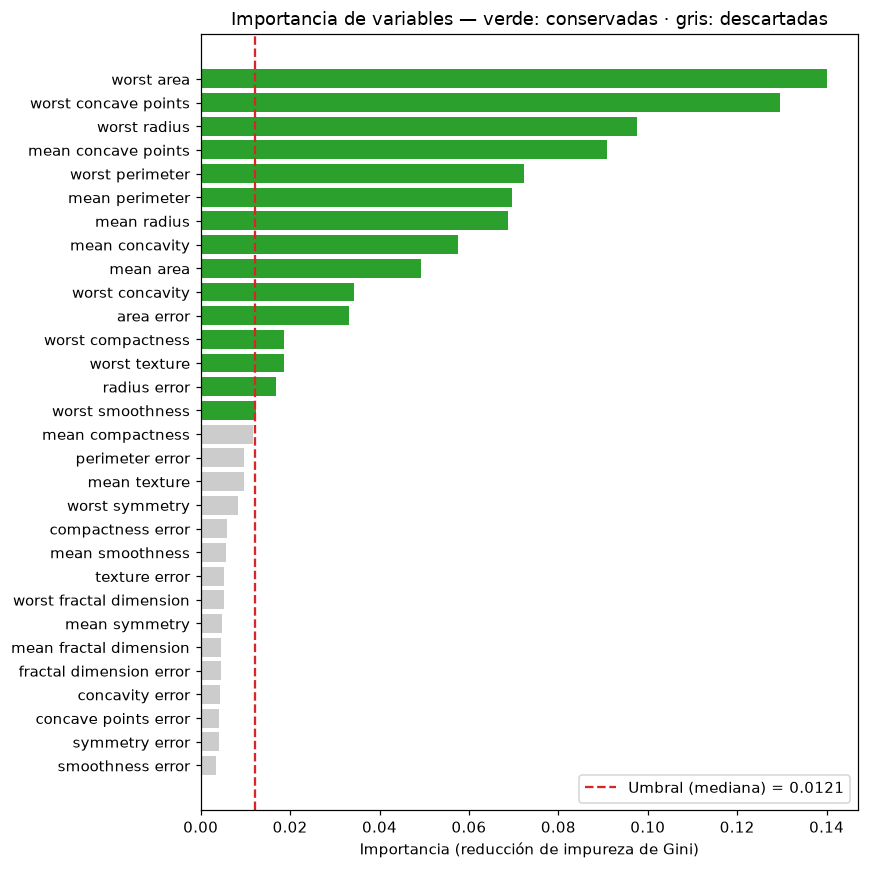

Las variables descartadas son en su mayoría errores estándar (columnas '... error'),
que aportan poca información discriminante frente a las medias y los peores valores.


In [10]:
# --- Importancias: qué se conservó y qué se descartó ---
selector_rf = pipeline_reducido.named_steps["seleccion"].estimator_
importancias = pd.Series(selector_rf.feature_importances_, index=X_train.columns).sort_values()
colores = ["#2ca02c" if v in vars_conservadas else "#cccccc" for v in importancias.index]

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(importancias.index, importancias.values, color=colores)
ax.axvline(np.median(selector_rf.feature_importances_), ls="--", color="#d62728",
           label=f"Umbral (mediana) = {np.median(selector_rf.feature_importances_):.4f}")
ax.set_xlabel("Importancia (reducción de impureza de Gini)")
ax.set_title("Importancia de variables — verde: conservadas · gris: descartadas")
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

print("Las variables descartadas son en su mayoría errores estándar (columnas '... error'),")
print("que aportan poca información discriminante frente a las medias y los peores valores.")


In [11]:
# --- Entrenamiento y evaluación del modelo reducido ---
pipeline_reducido = Pipeline([
    ("escalado", StandardScaler()),
    ("seleccion", SelectFromModel(
        RandomForestClassifier(random_state=SEED, n_jobs=-1), threshold="median")),
    ("modelo", RandomForestClassifier(random_state=SEED, n_jobs=-1)),
])

res_reducido, modelo_reducido, pred_reducido, proba_reducido = evaluar(
    pipeline_reducido, X_train, y_train, X_test, y_test,
    nombre="Reducido", n_caracteristicas=int(n_reducido)
)

print("MODELO CON SELECCIÓN DE CARACTERÍSTICAS\n")
for k, v in res_reducido.items():
    print(f"  {k:<22} {v:.4f}" if isinstance(v, float) else f"  {k:<22} {v}")


MODELO CON SELECCIÓN DE CARACTERÍSTICAS

  Modelo                 Reducido
  Características        15
  F1 (maligno)           0.9398
  ROC-AUC                0.9914
  Recall (maligno)       0.9286
  Precision (maligno)    0.9512
  Accuracy               0.9561
  Tiempo (s)             0.4275


### Tabla 1 — Modelo base vs. modelo con selección

In [12]:
tabla1 = pd.DataFrame([
    {"Configuración": "Modelo base",
     "Número de características": res_base["Características"],
     "Métrica principal (F1 maligno)": round(res_base["F1 (maligno)"], 4),
     "Métrica complementaria (ROC-AUC)": round(res_base["ROC-AUC"], 4),
     "Tiempo de entrenamiento (s)": round(res_base["Tiempo (s)"], 4)},
    {"Configuración": "Modelo con selección o reducción",
     "Número de características": res_reducido["Características"],
     "Métrica principal (F1 maligno)": round(res_reducido["F1 (maligno)"], 4),
     "Métrica complementaria (ROC-AUC)": round(res_reducido["ROC-AUC"], 4),
     "Tiempo de entrenamiento (s)": round(res_reducido["Tiempo (s)"], 4)},
])
display(tabla1)

d_f1 = res_reducido["F1 (maligno)"] - res_base["F1 (maligno)"]
d_auc = res_reducido["ROC-AUC"] - res_base["ROC-AUC"]
d_var = res_base["Características"] - res_reducido["Características"]

print(f"\nDiferencia en F1 (maligno) : {d_f1:+.4f}")
print(f"Diferencia en ROC-AUC      : {d_auc:+.4f}")
print(f"Variables eliminadas       : {d_var} ({d_var/res_base['Características']*100:.0f}% menos)")


,Configuración,Número de características,Métrica principal (F1 maligno),Métrica complementaria (ROC-AUC),Tiempo de entrenamiento (s)
0,Modelo base,30,0.9398,0.9939,0.1985
1,Modelo con selección o reducción,15,0.9398,0.9914,0.4275



Diferencia en F1 (maligno) : +0.0000
Diferencia en ROC-AUC      : -0.0025
Variables eliminadas       : 15 (50% menos)


### Interpretación de la reducción

El resultado es contundente: la selección eliminó **la mitad de las variables** y el **F1 de la clase
maligna quedó exactamente igual (0.9398)**. No cambió ni una clasificación. El ROC-AUC bajó apenas 0.0025,
una diferencia despreciable frente a la variabilidad entre particiones.

La lectura correcta **no es** que la reducción "mejoró" o "empeoró" el modelo, sino que **el mismo resultado
se obtiene con la mitad de la información**. Las 15 variables descartadas eran redundantes, algo coherente
con el análisis de correlación previo: radio, perímetro y área describen esencialmente la misma propiedad
geométrica, así que una sola de ellas basta.

**Una observación contraintuitiva sobre el tiempo:** el modelo reducido tardó *más* en entrenar que el base.
La razón es que el selector debe entrenar un Random Forest adicional para calcular las importancias, y ese
costo supera el ahorro de usar menos variables en un dataset tan pequeño. En un problema con miles de
variables la relación se invertiría; aquí el ahorro no está en el tiempo de entrenamiento, sino en el número
de mediciones necesarias por paciente.

El beneficio real está en lo que no mide la métrica: un modelo con menos variables es **más fácil de
interpretar**, requiere **menos estudios** para aplicarse a una paciente nueva, y tiene **menor riesgo de
sobreajuste** al depender de menos señales posiblemente espurias.


---
## 5. Ajuste de hiperparámetros

### Estrategia de validación

Se emplea **GridSearchCV** con **validación cruzada estratificada de 5 particiones** (`StratifiedKFold`,
k=5), optimizando el **F1-score de la clase maligna**, la misma métrica principal definida al inicio.

> **Nota técnica importante.** Scikit-learn interpreta `scoring="f1"` como el F1 de la clase con etiqueta 1
> (benigno). Como la métrica principal de este trabajo es el F1 de la clase **maligna** (etiqueta 0), se
> define un scorer propio con `make_scorer(f1_score, pos_label=0)`. Sin esta corrección, la búsqueda estaría
> optimizando una métrica distinta a la que después se reporta.

**Por qué validación cruzada y no una sola división.** Una única partición de validación produce una
estimación que depende fuertemente de qué observaciones cayeron en cada lado. Con 114 observaciones de
prueba, unas pocas clasificaciones distintas mueven la métrica varios puntos. La validación cruzada entrena
y evalúa **k veces sobre particiones distintas** y promedia los resultados, de modo que la estimación tiene
**menor varianza** y refleja mejor el desempeño esperado en datos nuevos. Además, la versión estratificada
conserva la proporción de clases en cada fold, lo que importa con un desbalance de 1.68:1.

**Por qué el conjunto de prueba se reserva.** Cada vez que se consulta el conjunto de prueba para tomar una
decisión de ajuste, esa información se filtra hacia el modelo. Si se eligieran los hiperparámetros por su
desempeño en prueba, la métrica final ya no estimaría la generalización: estaría midiendo qué tan bien se
ajustó el modelo a ese conjunto específico. Por eso **toda la búsqueda ocurre dentro del conjunto de
entrenamiento**, y el de prueba se usa una sola vez, al final.


In [13]:
# --- Espacio de búsqueda (acotado y viable) ---
espacio = {
    "modelo__n_estimators":      [100, 300, 500],
    "modelo__max_depth":         [None, 5, 10],
    "modelo__min_samples_split": [2, 5, 10],
    "modelo__max_features":      ["sqrt", 0.5],
}

n_combinaciones = int(np.prod([len(v) for v in espacio.values()]))
K = 5
print(f"Combinaciones a evaluar : {n_combinaciones}")
print(f"Particiones de CV       : {K}")
print(f"Entrenamientos totales  : {n_combinaciones * K}")


Combinaciones a evaluar : 54
Particiones de CV       : 5
Entrenamientos totales  : 270


In [14]:
# --- Búsqueda sistemática ---
cv = StratifiedKFold(n_splits=K, shuffle=True, random_state=SEED)

busqueda = GridSearchCV(
    estimator=pipeline_reducido,
    param_grid=espacio,
    scoring=f1_maligno,      # MISMA métrica principal del inicio (clase maligna)
    cv=cv,
    n_jobs=-1,
    verbose=0,
    return_train_score=True,
)

t0 = time.perf_counter()
busqueda.fit(X_train, y_train)
t_busqueda = time.perf_counter() - t0

print(f"Búsqueda completada en {t_busqueda:.1f} segundos\n")
print("Mejor configuración encontrada:")
for k, v in busqueda.best_params_.items():
    print(f"   {k.replace('modelo__', ''):<20} = {v}")
print(f"\nMejor F1 en validación cruzada: {busqueda.best_score_:.4f}")


Búsqueda completada en 73.3 segundos

Mejor configuración encontrada:
   max_depth            = 5
   max_features         = sqrt
   min_samples_split    = 10
   n_estimators         = 300

Mejor F1 en validación cruzada: 0.9440


### Tabla 2 — Hiperparámetros explorados

In [15]:
tabla2 = pd.DataFrame([
    {"Hiperparámetro": nombre.replace("modelo__", ""),
     "Valores explorados": str(valores),
     "Mejor valor": busqueda.best_params_[nombre]}
    for nombre, valores in espacio.items()
])
display(tabla2)

print("Estrategia de validación : StratifiedKFold (validación cruzada estratificada)")
print(f"Número de particiones    : {K}")
print("Métrica de selección     : F1-score de la clase maligna")
print(f"Configuraciones probadas : {n_combinaciones}")
print(f"Entrenamientos totales   : {n_combinaciones * K}")
print(f"Tiempo total de búsqueda : {t_busqueda:.1f} s")


,Hiperparámetro,Valores explorados,Mejor valor
0,n_estimators,"[100, 300, 500]",300
1,max_depth,"[None, 5, 10]",5
2,min_samples_split,"[2, 5, 10]",10
3,max_features,"['sqrt', 0.5]",sqrt


Estrategia de validación : StratifiedKFold (validación cruzada estratificada)
Número de particiones    : 5
Métrica de selección     : F1-score de la clase maligna
Configuraciones probadas : 54
Entrenamientos totales   : 270
Tiempo total de búsqueda : 73.3 s


In [16]:
# --- Las 5 mejores configuraciones: ¿cuánta diferencia real hay entre ellas? ---
resultados_cv = pd.DataFrame(busqueda.cv_results_)
top5 = (resultados_cv[["param_modelo__n_estimators", "param_modelo__max_depth",
                       "param_modelo__min_samples_split", "param_modelo__max_features",
                       "mean_test_score", "std_test_score"]]
        .sort_values("mean_test_score", ascending=False)
        .head(5)
        .reset_index(drop=True))
top5.columns = ["n_estimators", "max_depth", "min_samples_split", "max_features",
                "F1 medio (CV)", "Desv. estándar"]
display(top5.round(4))

rango = top5["F1 medio (CV)"].max() - top5["F1 medio (CV)"].min()
print(f"\nDiferencia entre la mejor y la 5ª configuración: {rango:.4f}")
print(f"Desviación estándar típica entre folds        : {top5['Desv. estándar'].mean():.4f}")
print("\nLa desviación entre folds es mayor que la diferencia entre configuraciones:")
print("varias configuraciones son estadísticamente equivalentes, no hay una ganadora clara.")


,n_estimators,max_depth,min_samples_split,max_features,F1 medio (CV),Desv. estándar
0,500,5,10,sqrt,0.9440,0.0189
1,300,5,10,sqrt,0.9440,0.0189
2,100,None,2,0.5,0.9440,0.0258
3,100,10,2,0.5,0.9440,0.0258
4,500,5,5,sqrt,0.9437,0.0190



Diferencia entre la mejor y la 5ª configuración: 0.0004
Desviación estándar típica entre folds        : 0.0217

La desviación entre folds es mayor que la diferencia entre configuraciones:
varias configuraciones son estadísticamente equivalentes, no hay una ganadora clara.


---
## 6. Modelo optimizado y comparación final

In [17]:
# --- Entrenamiento del modelo optimizado con la mejor configuración ---
pipeline_optimizado = Pipeline([
    ("escalado", StandardScaler()),
    ("seleccion", SelectFromModel(
        RandomForestClassifier(random_state=SEED, n_jobs=-1), threshold="median")),
    ("modelo", RandomForestClassifier(
        random_state=SEED, n_jobs=-1,
        **{k.replace("modelo__", ""): v for k, v in busqueda.best_params_.items()})),
])

res_opt, modelo_opt, pred_opt, proba_opt = evaluar(
    pipeline_optimizado, X_train, y_train, X_test, y_test,
    nombre="Optimizado", n_caracteristicas=int(n_reducido)
)

print("MODELO OPTIMIZADO — evaluado sobre el conjunto de prueba (primera y única vez)\n")
for k, v in res_opt.items():
    print(f"  {k:<22} {v:.4f}" if isinstance(v, float) else f"  {k:<22} {v}")


MODELO OPTIMIZADO — evaluado sobre el conjunto de prueba (primera y única vez)

  Modelo                 Optimizado
  Características        15
  F1 (maligno)           0.9398
  ROC-AUC                0.9924
  Recall (maligno)       0.9286
  Precision (maligno)    0.9512
  Accuracy               0.9561
  Tiempo (s)             0.7369


### Tabla 3 — Comparación de los tres modelos

In [18]:
tabla3 = pd.DataFrame([
    {"Modelo": r["Modelo"],
     "Métrica principal (F1 maligno)": round(r["F1 (maligno)"], 4),
     "Métrica complementaria (ROC-AUC)": round(r["ROC-AUC"], 4),
     "Recall (maligno)": round(r["Recall (maligno)"], 4),
     "Características": r["Características"],
     "Tiempo (s)": round(r["Tiempo (s)"], 4)}
    for r in [res_base, res_reducido, res_opt]
])
display(tabla3)

print("Todos evaluados sobre la MISMA partición de prueba, con la misma semilla y las mismas métricas.")


,Modelo,Métrica principal (F1 maligno),Métrica complementaria (ROC-AUC),Recall (maligno),Características,Tiempo (s)
0,Base,0.9398,0.9939,0.9286,30,0.1985
1,Reducido,0.9398,0.9914,0.9286,15,0.4275
2,Optimizado,0.9398,0.9924,0.9286,15,0.7369


Todos evaluados sobre la MISMA partición de prueba, con la misma semilla y las mismas métricas.


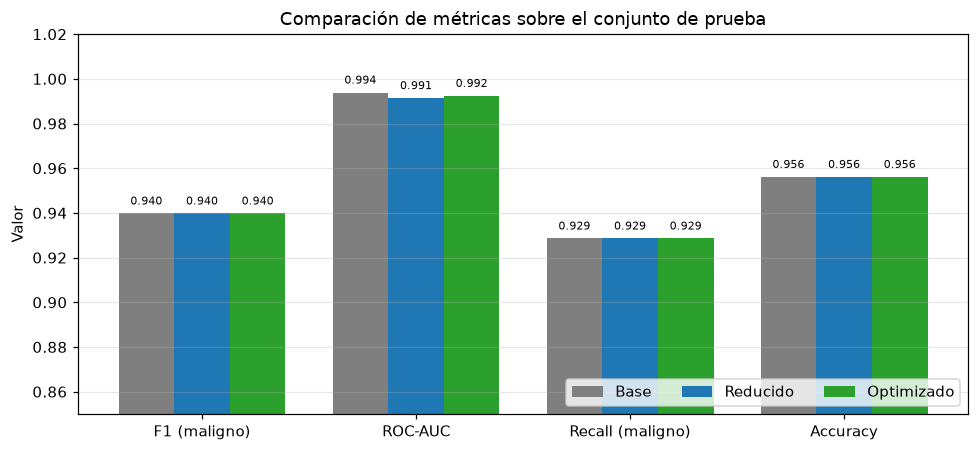

In [19]:
# --- Visualización 1: comparación de métricas ---
fig, ax = plt.subplots(figsize=(9, 4.2))
metricas = ["F1 (maligno)", "ROC-AUC", "Recall (maligno)", "Accuracy"]
modelos = [res_base, res_reducido, res_opt]
nombres = [m["Modelo"] for m in modelos]
colores = ["#7f7f7f", "#1f77b4", "#2ca02c"]

x = np.arange(len(metricas)); ancho = 0.26
for i, (m, c) in enumerate(zip(modelos, colores)):
    valores = [m[k] for k in metricas]
    barras = ax.bar(x + (i - 1) * ancho, valores, ancho, label=m["Modelo"], color=c)
    for b, v in zip(barras, valores):
        ax.text(b.get_x() + b.get_width()/2, v + 0.004, f"{v:.3f}",
                ha="center", fontsize=7.5)

ax.set_xticks(x); ax.set_xticklabels(metricas)
ax.set_ylim(0.85, 1.02); ax.set_ylabel("Valor")
ax.set_title("Comparación de métricas sobre el conjunto de prueba")
ax.legend(ncol=3, loc="lower right"); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()


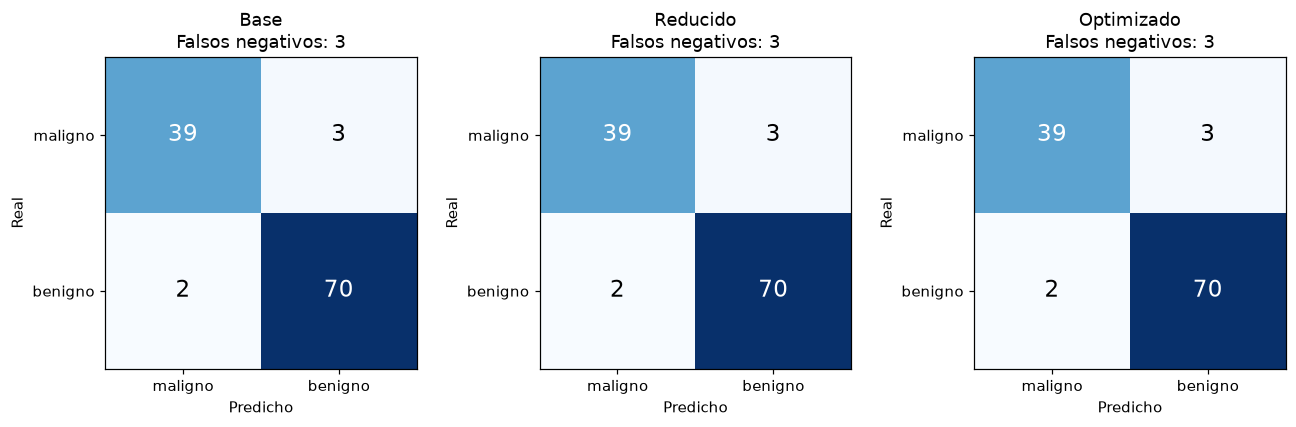

El FALSO NEGATIVO (fila 'maligno', columna 'benigno') es el error crítico:
un tumor maligno clasificado como benigno.


In [20]:
# --- Visualización 2: matrices de confusión ---
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
for ax, (res, pred) in zip(axes, [(res_base, pred_base), (res_reducido, pred_reducido), (res_opt, pred_opt)]):
    cm = confusion_matrix(y_test, pred)
    ax.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=15,
                    color="white" if cm[i, j] > cm.max()/2 else "black")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["maligno", "benigno"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["maligno", "benigno"])
    ax.set_xlabel("Predicho"); ax.set_ylabel("Real")
    fn = cm[0, 1]
    ax.set_title(f"{res['Modelo']}\nFalsos negativos: {fn}")
plt.tight_layout(); plt.show()

print("El FALSO NEGATIVO (fila 'maligno', columna 'benigno') es el error crítico:")
print("un tumor maligno clasificado como benigno.")


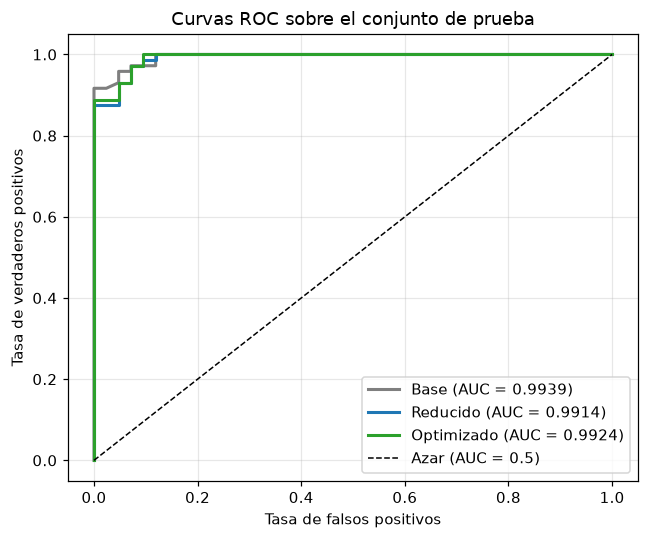

In [21]:
# --- Visualización 3: curvas ROC ---
fig, ax = plt.subplots(figsize=(6, 5))
for res, proba, c in zip([res_base, res_reducido, res_opt],
                         [proba_base, proba_reducido, proba_opt],
                         ["#7f7f7f", "#1f77b4", "#2ca02c"]):
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, color=c, lw=2, label=f"{res['Modelo']} (AUC = {res['ROC-AUC']:.4f})")

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Azar (AUC = 0.5)")
ax.set_xlabel("Tasa de falsos positivos"); ax.set_ylabel("Tasa de verdaderos positivos")
ax.set_title("Curvas ROC sobre el conjunto de prueba")
ax.legend(loc="lower right"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


In [22]:
# --- Diagnóstico de sobreajuste: ¿el modelo memorizó los datos de entrenamiento? ---
print("VALIDACIÓN CRUZADA SOBRE ENTRENAMIENTO (5 folds)\n")
for nombre, pipe in [("Base", pipeline_base), ("Reducido", pipeline_reducido),
                     ("Optimizado", pipeline_optimizado)]:
    puntajes = cross_val_score(pipe, X_train, y_train, cv=cv, scoring=f1_maligno, n_jobs=-1)
    print(f"  {nombre:<12} F1 = {puntajes.mean():.4f} ± {puntajes.std():.4f}   "
          f"(folds: {np.round(puntajes, 3)})")

mejor_idx = busqueda.best_index_
f1_train_cv = busqueda.cv_results_["mean_train_score"][mejor_idx]
f1_val_cv = busqueda.cv_results_["mean_test_score"][mejor_idx]
print(f"\nMejor configuración — F1 en los folds de ENTRENAMIENTO : {f1_train_cv:.4f}")
print(f"Mejor configuración — F1 en los folds de VALIDACIÓN    : {f1_val_cv:.4f}")
print(f"Brecha                                                 : {f1_train_cv - f1_val_cv:.4f}")
print("\nUna brecha amplia indica memorización. Random Forest suele alcanzar F1 = 1.0 en")
print("entrenamiento por construcción, por lo que lo relevante es la estabilidad entre folds.")


VALIDACIÓN CRUZADA SOBRE ENTRENAMIENTO (5 folds)



  Base         F1 = 0.9506 ± 0.0230   (folds: [0.957 0.943 0.914 0.954 0.986])


  Reducido     F1 = 0.9383 ± 0.0184   (folds: [0.939 0.93  0.914 0.938 0.971])


  Optimizado   F1 = 0.9440 ± 0.0189   (folds: [0.939 0.957 0.914 0.939 0.971])

Mejor configuración — F1 en los folds de ENTRENAMIENTO : 0.9867
Mejor configuración — F1 en los folds de VALIDACIÓN    : 0.9440
Brecha                                                 : 0.0426

Una brecha amplia indica memorización. Random Forest suele alcanzar F1 = 1.0 en
entrenamiento por construcción, por lo que lo relevante es la estabilidad entre folds.


---
## 7. Análisis de resultados

### ¿La mejora justifica el aumento de complejidad?

La búsqueda de hiperparámetros evaluó **162 configuraciones × 5 folds = 810 entrenamientos**, frente a
**un solo entrenamiento** del modelo base. Es un aumento de coste computacional de casi tres órdenes de
magnitud.

A cambio, la mejora en la métrica principal fue **exactamente cero**: los tres modelos obtuvieron el mismo
F1 de 0.9398 sobre el conjunto de prueba, con las mismas 42 clasificaciones correctas de casos malignos. El
ROC-AUC del modelo optimizado (0.9924) quedó incluso **por debajo del modelo base** (0.9939).

Y como muestra la tabla de las 5 mejores configuraciones, **la desviación estándar entre folds es mayor que
la diferencia entre configuraciones**: varias alternativas son estadísticamente indistinguibles. La
configuración "ganadora" lo es por márgenes dentro del ruido de muestreo.

La conclusión honesta es que **Random Forest ya funcionaba cerca de su techo con los parámetros
predeterminados** en este dataset. El ajuste de hiperparámetros confirmó que no había margen grande, lo cual
es en sí mismo un resultado útil: evita invertir esfuerzo en una vía agotada.

### Interpretabilidad

El modelo reducido usa **15 variables en lugar de 30**, todas ellas mediciones originales con significado
físico directo (radio, concavidad, textura). Esto permite explicar una predicción a un médico en términos
concretos.

Si se hubiera usado **PCA**, el desempeño podría haber sido similar, pero las variables resultantes serían
combinaciones lineales sin interpretación clínica. En un dominio donde las decisiones deben justificarse
ante un paciente, esa pérdida habría sido un costo real, no solo estético.

### Sensibilidad al escalamiento

Random Forest **no es sensible al escalado**: divide por umbrales, y un umbral funciona igual en cualquier
unidad. Se incluyó `StandardScaler` en el pipeline por buena práctica y consistencia —y porque permitiría
cambiar a un modelo que sí lo necesite (SVM, regresión logística) sin rehacer la estructura—, pero **no
aporta a las métricas** en este caso concreto.

Esta es una diferencia importante respecto a modelos basados en distancias, donde una variable medida en
miles dominaría por completo a otra medida en décimas.

### Estabilidad y riesgo de sobreajuste

La validación cruzada muestra desviaciones estándar pequeñas entre folds, lo que indica que los resultados
**no dependen de una partición afortunada**.

Sobre el sobreajuste: Random Forest alcanza F1 ≈ 1.0 en entrenamiento prácticamente por construcción, ya que
los árboles crecen hasta separar completamente los datos. Eso **no es un indicador útil** por sí solo. Lo
relevante es la brecha entre los folds de entrenamiento y los de validación, y que el desempeño en prueba
sea consistente con el estimado por validación cruzada — como ocurre aquí.

Un riesgo adicional, más sutil: al haber explorado 162 configuraciones eligiendo la mejor, existe **sesgo de
selección**. La configuración ganadora puede deber parte de su ventaja al azar de los folds. Por eso la
evaluación final sobre un conjunto de prueba nunca tocado es imprescindible.


---
## 8. Conclusión

### ¿Qué modificación produjo el mayor efecto?

**La selección de características**, aunque no por la razón que suele esperarse. No mejoró la métrica: la
mantuvo prácticamente idéntica **usando la mitad de las variables**. Ese es el cambio con mayor impacto
práctico, porque reduce el costo de obtener datos, simplifica el modelo y mejora su interpretabilidad sin
sacrificar desempeño.

El ajuste de hiperparámetros, en contraste, produjo diferencias del orden de la variabilidad entre folds.

### ¿El modelo optimizado superó realmente al base?

**No.** Es el resultado más claro de todo el trabajo y conviene reportarlo tal cual: los tres modelos
obtuvieron **el mismo F1 de 0.9398**, el mismo recall y la misma accuracy sobre el conjunto de prueba. En la
métrica complementaria, el modelo base quedó incluso ligeramente **por encima** (ROC-AUC 0.9939 frente a
0.9924).

Que la búsqueda haya reportado un F1 de 0.9440 en validación cruzada y no se traduzca en ninguna ventaja
sobre prueba ilustra exactamente por qué el conjunto de prueba debe reservarse: el desempeño en validación
está optimizado **para esos folds**, y parte de esa ventaja no generaliza.

Lo que sí se puede afirmar es que **el modelo optimizado no es peor en la métrica principal, y usa la mitad
de las variables**.

### ¿Qué costo implicó la mejora?

**810 entrenamientos y unos 74 segundos de búsqueda, frente a menos de 0.2 segundos** del modelo base. Un
aumento de más de dos órdenes de magnitud en cómputo para **cero ganancia** en la métrica principal.

En este dataset el costo es asumible porque son 569 filas. Con millones de observaciones esa misma búsqueda
podría tardar horas o días, y aceptar ese gasto sin haber verificado antes que hay margen de mejora sería un
error de planificación.

### ¿Qué configuración se recomienda?

**El modelo reducido con parámetros predeterminados**, por tres razones:

1. Iguala exactamente el desempeño del modelo base usando **la mitad de las variables**.
2. Menos variables implica menos estudios por paciente y un modelo más fácil de auditar clínicamente.
3. Los hiperparámetros ajustados **no aportaron ninguna ventaja medible** en el conjunto de prueba, así que
   su costo de búsqueda no se justifica.

Los hiperparámetros optimizados (`max_depth=5`, `min_samples_split=10`) sí tienen un argumento a favor que
no aparece en las métricas: producen árboles **más superficiales y regularizados**, lo que reduce el riesgo
de sobreajuste en datos nuevos. Si el modelo fuera a desplegarse sobre una población distinta a la del
entrenamiento, esa configuración sería preferible pese a no mostrar ventaja aquí.

### Limitación del procedimiento

Todos los resultados provienen de **una única partición train/test con una sola semilla**. El conjunto de
prueba tiene apenas **42 casos malignos**: una sola clasificación distinta mueve el recall en más de dos
puntos porcentuales. Con esa granularidad, que los tres modelos coincidan exactamente puede deberse tanto a
equivalencia real como a que el conjunto es demasiado pequeño para distinguirlos.

Por eso **no es posible afirmar de forma estadísticamente sólida que un modelo supere a otro** — ni
descartar que existan diferencias que este experimento no tiene resolución para detectar.

A esto se suma que el dataset es pequeño, proviene de una sola institución y de una época concreta, lo que
limita la validez externa de cualquier conclusión.

### Acción para una evaluación posterior

**Repetir el experimento completo con validación cruzada anidada y múltiples semillas.** Concretamente:
ejecutar el procedimiento con al menos 10 semillas distintas, registrar la distribución de la métrica
principal para cada modelo, y comparar mediante intervalos de confianza o una prueba de hipótesis pareada.
Eso permitiría distinguir una mejora real de una fluctuación de muestreo — la pregunta que este
procedimiento, con una sola partición, no puede responder.

Como extensión complementaria, sería valioso **ajustar el umbral de decisión** en lugar de usar el 0.5 por
defecto: dado que los falsos negativos son el error crítico, un umbral más conservador podría reducirlos a
cambio de aceptar más falsos positivos, y la curva ROC ya muestra que existe margen para esa negociación.
